In [1]:
import pandas as pd
import matplotlib.pyplot as plt
matches = pd.read_csv("C:/Users/acer/Downloads/matches.csv")


In [2]:
print(matches)

           id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

                                       

In [3]:
print(matches.shape)

print(matches.head())

print(matches.columns)

print(matches.dtypes)

print("Unique IDs:", matches["id"].nunique())
print("Total Rows:", len(matches))

(1095, 20)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0   

In [4]:
print(matches.isnull().sum())

print("Duplicate Rows:", matches.duplicated().sum())

matches = matches.drop_duplicates()

matches["winner"] = matches["winner"].fillna("No Result")
matches["player_of_match"] = matches["player_of_match"].fillna("Unknown")

if "method" in matches.columns:
    matches["method"] = matches["method"].fillna("Normal")

matches["result_margin"] = matches["result_margin"].fillna(0)

print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64
Duplicate Rows: 0
id                  0
season              0
city               51
date                0
match_type          0
player_of_match     0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              0
result              0
result_margin       0
target_runs         3
target_overs        3
super_over          0
method              0
umpire1             0
umpire2             0
dtype: int64


season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64
Season: 2013
Matches: 76


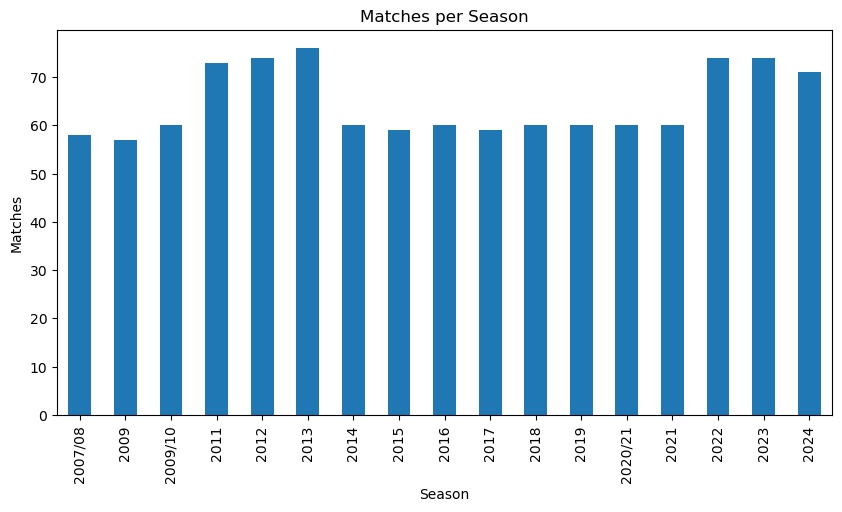

In [5]:
season_matches = matches.groupby("season")["id"].count()

print(season_matches)

print("Season:", season_matches.idxmax())
print("Matches:", season_matches.max())

season_matches.plot(kind="bar", figsize=(10,5))
plt.xlabel("Season")
plt.ylabel("Matches")
plt.title("Matches per Season")
plt.show()

Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
No Result                        5
Name: winner, dtype: int64
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Name: winner, dtype: int64


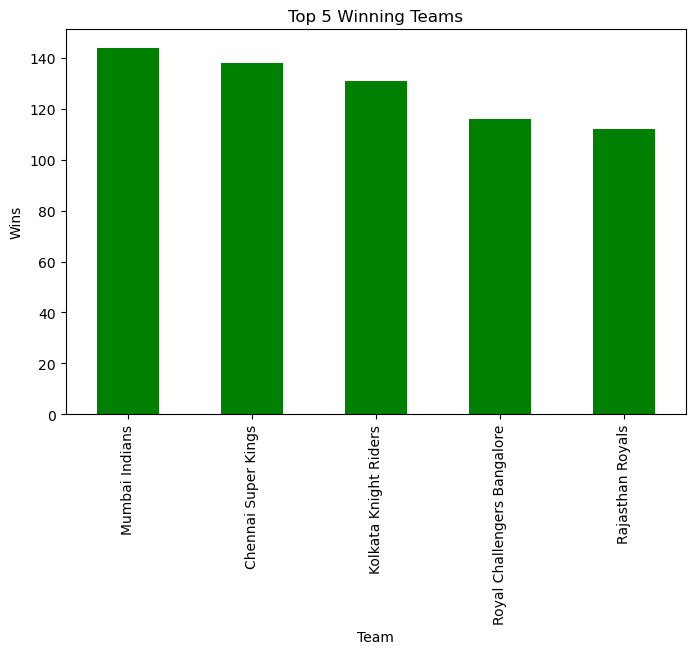

In [6]:
wins = matches["winner"].value_counts()

print(wins)

top5 = wins.head(5)

print(top5)

top5.plot(kind="bar", figsize=(8,5), color="green")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.title("Top 5 Winning Teams")
plt.show()

In [7]:
csk = matches[matches["winner"] == "Chennai Super Kings"]

print(csk)

print("Total Wins:", len(csk))

           id   season        city        date match_type  player_of_match  \
1      335983  2007/08  Chandigarh  2008-04-19     League       MEK Hussey   
7      335989  2007/08     Chennai  2008-04-23     League        ML Hayden   
11     335993  2007/08     Chennai  2008-04-26     League         JDP Oram   
14     335996  2007/08   Bangalore  2008-04-28     League         MS Dhoni   
27     336009  2007/08       Delhi  2008-05-08     League         MS Dhoni   
...       ...      ...         ...         ...        ...              ...   
1045  1426260     2024     Chennai  2024-04-08     League        RA Jadeja   
1052  1426267     2024      Mumbai  2024-04-14     League      M Pathirana   
1069  1426284     2024     Chennai  2024-04-28     League       RD Gaikwad   
1076  1426291     2024  Dharamsala  2024-05-05     League        RA Jadeja   
1084  1426299     2024     Chennai  2024-05-12     League  Simarjeet Singh   

                                                  venue  \
1   

field    704
bat      391
Name: toss_decision, dtype: int64


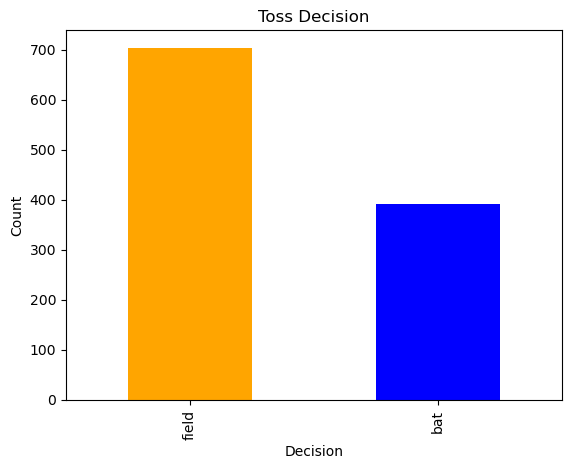

In [8]:
toss = matches["toss_decision"].value_counts()

print(toss)

toss.plot(kind="bar", color=["orange", "blue"])
plt.xlabel("Decision")
plt.ylabel("Count")
plt.title("Toss Decision")
plt.show()

toss_decision  bat  field
season                   
2007/08         26     32
2009            35     22
2009/10         39     21
2011            25     48
2012            37     37
2013            45     31
2014            19     41
2015            25     34
2016            11     49
2017            11     48
2018            10     50
2019            10     50
2020/21         27     33
2021            16     44
2022            15     59
2023            21     53
2024            19     52


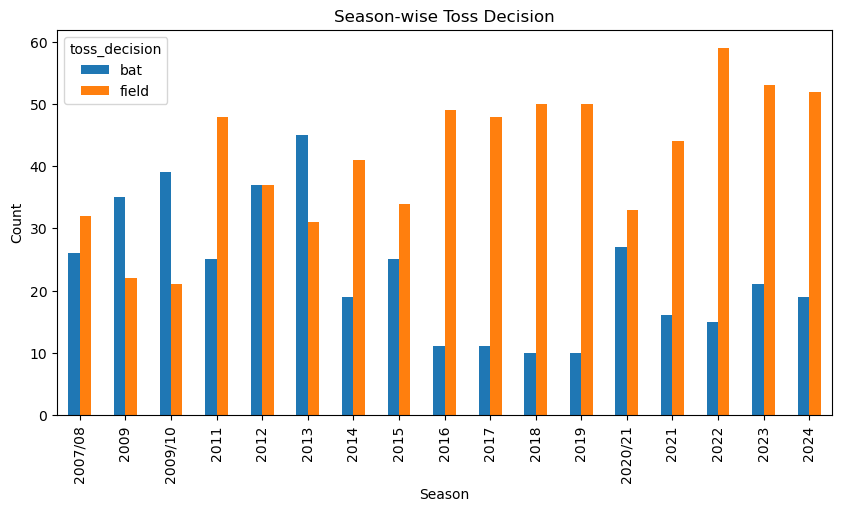

In [9]:
pivot = pd.crosstab(matches["season"], matches["toss_decision"])

print(pivot)

pivot.plot(kind="bar", figsize=(10,5))
plt.xlabel("Season")
plt.ylabel("Count")
plt.title("Season-wise Toss Decision")
plt.show()

Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai                                 28
Narendra Mod

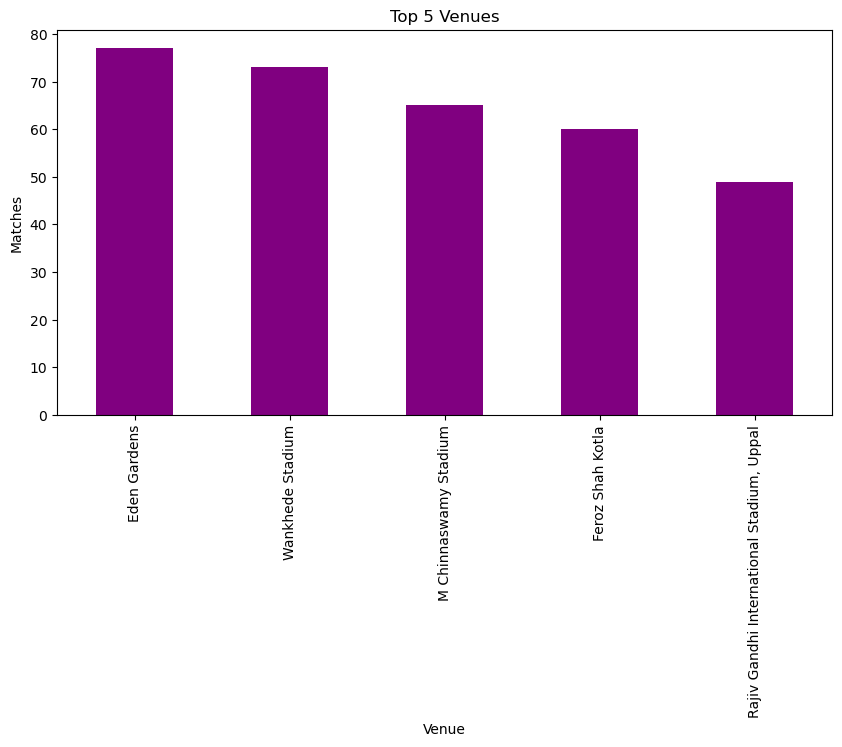

In [10]:
venue = matches["venue"].value_counts()

print(venue)

top5 = venue.head(5)

print(top5)

top5.plot(kind="bar", figsize=(10,5), color="purple")
plt.xlabel("Venue")
plt.ylabel("Matches")
plt.title("Top 5 Venues")
plt.show()

In [11]:
print("Largest Margin:", matches["result_margin"].max())

largest = matches[matches["result_margin"] == matches["result_margin"].max()]

print(largest)

top10 = matches.sort_values(by="result_margin", ascending=False).head(10)

print(top10[["season", "team1", "team2", "winner", "result_margin"]])

Largest Margin: 146.0
          id season   city        date match_type player_of_match  \
620  1082635   2017  Delhi  2017-05-06     League     LMP Simmons   

                venue             team1           team2       toss_winner  \
620  Feroz Shah Kotla  Delhi Daredevils  Mumbai Indians  Delhi Daredevils   

    toss_decision          winner result  result_margin  target_runs  \
620         field  Mumbai Indians   runs          146.0        213.0   

     target_overs super_over  method      umpire1    umpire2  
620          20.0          N  Normal  Nitin Menon  CK Nandan  
       season                        team1                        team2  \
620      2017             Delhi Daredevils               Mumbai Indians   
560      2016  Royal Challengers Bangalore                Gujarat Lions   
0     2007/08  Royal Challengers Bangalore        Kolkata Knight Riders   
496      2015  Royal Challengers Bangalore              Kings XI Punjab   
352      2013  Royal Challengers Banga

['Won by Runs' 'Won by Wickets' 'Tie' 'No Result']
Won by Wickets    578
Won by Runs       498
Tie                14
No Result           5
Name: win_type, dtype: int64


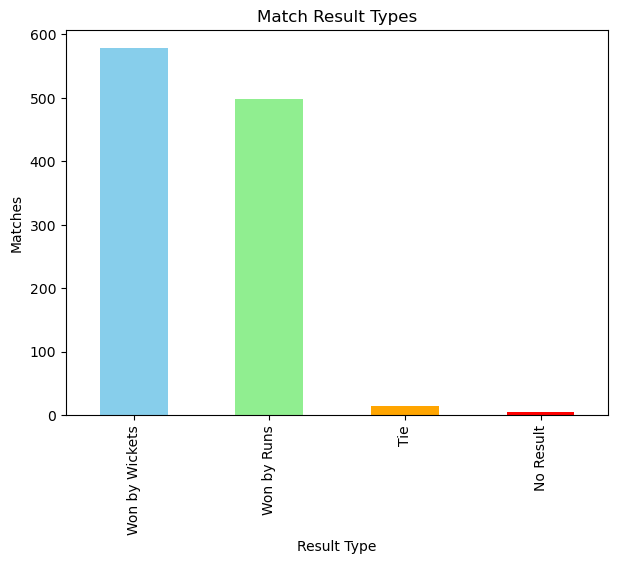

In [12]:
def win_type(result):
    if result == "runs":
        return "Won by Runs"
    elif result == "wickets":
        return "Won by Wickets"
    elif result == "tie":
        return "Tie"
    else:
        return "No Result"

matches["win_type"] = matches["result"].apply(win_type)

print(matches["win_type"].unique())

count = matches["win_type"].value_counts()

print(count)

count.plot(kind="bar", figsize=(7,5), color=["skyblue", "lightgreen", "orange", "red"])
plt.xlabel("Result Type")
plt.ylabel("Matches")
plt.title("Match Result Types")
plt.show()

In [13]:
matches["date"] = pd.to_datetime(matches["date"])

matches["year"] = matches["date"].dt.year

def win_type(result):
    if result == "runs":
        return "Won by Runs"
    elif result == "wickets":
        return "Won by Wickets"
    elif result == "tie":
        return "Tie"
    else:
        return "No Result"

matches["win_type"] = matches["result"].apply(win_type)

print(matches[["date", "year"]].head())

print(matches[["result", "win_type"]].head())

matches.to_csv("matches_cleaned.csv", index=False)

        date  year
0 2008-04-18  2008
1 2008-04-19  2008
2 2008-04-19  2008
3 2008-04-20  2008
4 2008-04-20  2008
    result        win_type
0     runs     Won by Runs
1     runs     Won by Runs
2  wickets  Won by Wickets
3  wickets  Won by Wickets
4  wickets  Won by Wickets
